# INHALEX - Propuesta 2: prediccion mensual de demanda

## CRISP-DM 1/6 - Comprension del negocio

Esta libreta desarrolla una **regresion numerica** para estimar cuantas unidades de cada inhalador se solicitaran durante el siguiente mes.

| Elemento | Definicion |
| --- | --- |
| Necesidad | Anticipar la demanda mensual para apoyar el reabasto. |
| Unidad de analisis | Una fila representa un producto en un mes. |
| Variable objetivo Y | `Y_unidades_solicitadas_mes`: unidades solicitadas de un producto durante `mes_objetivo`. |
| Variables X | Demanda de los tres meses previos, pedidos, precio, calificacion, numero de resenas, mes y categoria. |
| Usuario | Administrador de INHALEX. |
| Decision | Identificar productos con posible necesidad de reabasto. |
| Salida | Prediccion continua de unidades por producto-mes. |

El CSV se usa solo para desarrollar y validar. En produccion, Flask debera reconstruir las mismas variables desde MongoDB; no cargara este dataset.

## CRISP-DM 2/6 - Origen y significado de los datos

El dataset se obtuvo mediante un proceso reproducible de datos sinteticos de INHALEX. La futura fuente operativa es MongoDB:

`pedidos.items[] + productos + resenas_producto -> agregacion producto-mes -> variables X -> Ridge -> prediccion mensual`

- `pedidos`: aporta producto, cantidad solicitada, precio y fecha del pedido.
- `productos`: aporta el identificador y la categoria del inhalador.
- `resenas_producto`: aporta calificacion y fecha, solo si ya existian antes del mes a predecir.

Las variables historicas se calculan antes de `mes_objetivo`; por eso no se usa informacion futura para predecir el mes analizado.

In [119]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

rutas_posibles = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
REPO_ROOT = next(
    (ruta for ruta in rutas_posibles if (ruta / 'ml' / 'exports').exists()),
    None,
)
assert REPO_ROOT is not None, 'No fue posible ubicar la raiz del proyecto INHALEX.'

EXPORTS_DIR = REPO_ROOT / 'ml' / 'exports'
ARTIFACT_DIR = REPO_ROOT / 'ml' / 'artifacts'
TARGET = 'Y_unidades_solicitadas_mes'
SEED = 20260717

assert (EXPORTS_DIR / 'dataset_prediccion_demanda.csv').exists(), 'No se encontro el dataset de demanda.'
assert ARTIFACT_DIR.exists(), 'No se encontro la carpeta ml/artifacts.'

pd.set_option('display.max_columns', None)


### Carga del dataset

Primero se carga el archivo, se convierten las fechas y se muestra una muestra. No se modifica ningun valor en esta etapa.

In [120]:
demanda = pd.read_csv(
    EXPORTS_DIR / 'dataset_prediccion_demanda.csv',
    dtype={'product_id': 'string', 'producto': 'string', 'categoria': 'string'},
)

demanda['fecha_corte'] = pd.to_datetime(demanda['fecha_corte'], errors='coerce')
demanda['mes_objetivo'] = pd.to_datetime(demanda['mes_objetivo'], format='%Y-%m', errors='coerce')

# Vista documental: dimensiones, tipos de dato y primeras observaciones.
resumen_carga = pd.DataFrame({
    'filas': [demanda.shape[0]],
    'columnas': [demanda.shape[1]],
    'tipos_presentes': [', '.join(sorted(demanda.dtypes.astype(str).unique()))],
})
display(resumen_carga)
display(demanda.dtypes.astype(str).rename('tipo_de_dato').to_frame())
demanda.head()

,filas,columnas,tipos_presentes
0,288,17,"bool, datetime64[us], float64, int64, str, string"


,tipo_de_dato
fecha_corte,datetime64[us]
mes_objetivo,datetime64[us]
product_id,string
producto,string
categoria,string
demanda_lag_1m,float64
demanda_lag_2m,float64
demanda_lag_3m,float64
promedio_demanda_3m,float64
pedidos_lag_1m,float64


,fecha_corte,mes_objetivo,product_id,producto,categoria,demanda_lag_1m,demanda_lag_2m,demanda_lag_3m,promedio_demanda_3m,pedidos_lag_1m,precio_promedio_lag_1m,rating_promedio_al_corte,cantidad_resenas_al_corte,numero_mes,Y_unidades_solicitadas_mes,generation_run_id,is_synthetic
0,2024-12-31,2025-01-01,SYN-PROD-001,Toronjil,linea-insomnio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,inhalex-synthetic-v1,True
1,2024-12-31,2025-01-01,SYN-PROD-002,Mirra y Azafrán,linea-ansiedad-estres,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,inhalex-synthetic-v1,True
2,2024-12-31,2025-01-01,SYN-PROD-003,Copal,linea-estimulante,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,2,inhalex-synthetic-v1,True
3,2024-12-31,2025-01-01,SYN-PROD-004,Anís Estrella,linea-ansiedad-estres,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,inhalex-synthetic-v1,True
4,2024-12-31,2025-01-01,SYN-PROD-005,Eucalipto,linea-verde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,inhalex-synthetic-v1,True


In [121]:
seed_info = json.loads((EXPORTS_DIR / 'operational-seed.json').read_text(encoding='utf-8'))

origen_datos = pd.DataFrame([
    ['pedidos sinteticos', len(seed_info['orders']), 'Fuente de cantidades, precios y fechas'],
    ['items de pedido', sum(len(order['items']) for order in seed_info['orders']), 'Fuente de producto y cantidad solicitada'],
    ['resenas sinteticas', len(seed_info['reviews']), 'Fuente de rating acumulado al corte'],
    ['productos del catalogo', len(seed_info['catalog']), 'Fuente de categoria e identificador'],
    ['filas producto-mes', len(demanda), 'Dataset final para regresion'],
], columns=['origen', 'cantidad', 'uso'])

metadata_sintetica = pd.DataFrame([
    ['generation_run_id', seed_info['metadata']['generation_run_id']],
    ['semilla', seed_info['metadata']['random_seed']],
    ['periodo', seed_info['metadata']['start_date'] + ' a ' + seed_info['metadata']['end_date']],
    ['proporcion sintetica', '100 %; datos ficticios reproducibles'],
], columns=['metadato', 'valor'])

display(origen_datos)
metadata_sintetica

,origen,cantidad,uso
0,pedidos sinteticos,1800,"Fuente de cantidades, precios y fechas"
1,items de pedido,4054,Fuente de producto y cantidad solicitada
2,resenas sinteticas,586,Fuente de rating acumulado al corte
3,productos del catalogo,16,Fuente de categoria e identificador
4,filas producto-mes,288,Dataset final para regresion


,metadato,valor
0,generation_run_id,inhalex-synthetic-v1
1,semilla,20260717
2,periodo,2025-01-01 a 2026-06-30
3,proporcion sintetica,100 %; datos ficticios reproducibles


## Calidad de datos

Se revisan dimensiones, duplicados, tipos y nulos antes de preparar el modelo. La libreta no crea nulos artificiales.

In [122]:
perfil_calidad = pd.DataFrame({
    'tipo': demanda.dtypes.astype(str),
    'nulos': demanda.isna().sum(),
    'valores_distintos': demanda.nunique(),
})

llave_producto_mes_duplicada = demanda.duplicated(['product_id', 'mes_objetivo']).sum()
resumen_integridad = pd.DataFrame({
    'verificacion': ['Filas producto-mes duplicadas', 'Filas completas duplicadas'],
    'resultado': [llave_producto_mes_duplicada, demanda.duplicated().sum()]
})
display(resumen_integridad)
perfil_calidad

,verificacion,resultado
0,Filas producto-mes duplicadas,0
1,Filas completas duplicadas,0


,tipo,nulos,valores_distintos
fecha_corte,datetime64[us],0,18
mes_objetivo,datetime64[us],0,18
product_id,string,0,16
producto,string,0,16
categoria,string,0,5
demanda_lag_1m,float64,16,48
demanda_lag_2m,float64,32,43
demanda_lag_3m,float64,48,42
promedio_demanda_3m,float64,48,93
pedidos_lag_1m,float64,16,38


In [123]:
nulos_originales = pd.DataFrame({
    'columna': demanda.columns,
    'nulos': demanda.isna().sum().values,
    'porcentaje': demanda.isna().mean().mul(100).round(2).values,
})

nulos_originales[nulos_originales['nulos'] > 0]

,columna,nulos,porcentaje
5,demanda_lag_1m,16,5.56
6,demanda_lag_2m,32,11.11
7,demanda_lag_3m,48,16.67
8,promedio_demanda_3m,48,16.67
9,pedidos_lag_1m,16,5.56
10,precio_promedio_lag_1m,32,11.11
11,rating_promedio_al_corte,64,22.22


Los nulos de los rezagos aparecen al inicio de la serie: un producto no puede tener tres meses anteriores durante sus primeros meses observados. No se inventan esos datos; esas filas se excluyen del entrenamiento porque el modelo requiere los tres rezagos.

Despues de este filtro se revisan nuevamente los nulos. Solo `precio_promedio_lag_1m` y `rating_promedio_al_corte` que realmente falten se completaran con la mediana del conjunto de entrenamiento correspondiente. La mediana nunca se calcula con validacion ni prueba.

In [124]:
columnas_rezago = ['demanda_lag_1m', 'demanda_lag_2m', 'demanda_lag_3m']

demanda_modelable = demanda.dropna(subset=columnas_rezago).copy()

filas_excluidas_por_historial = len(demanda) - len(demanda_modelable)
resumen_historial = pd.DataFrame([
    ['Filas originales', len(demanda)],
    ['Filas con tres rezagos completos', len(demanda_modelable)],
    ['Filas excluidas por historial insuficiente', filas_excluidas_por_historial],
], columns=['medida', 'valor'])

resumen_historial

,medida,valor
0,Filas originales,288
1,Filas con tres rezagos completos,240
2,Filas excluidas por historial insuficiente,48


In [125]:
nulos_modelables = pd.DataFrame({
    'columna': demanda_modelable.columns,
    'nulos': demanda_modelable.isna().sum().values,
    'porcentaje': demanda_modelable.isna().mean().mul(100).round(2).values,
})

nulos_modelables[nulos_modelables['nulos'] > 0]

,columna,nulos,porcentaje
10,precio_promedio_lag_1m,1,0.42
11,rating_promedio_al_corte,17,7.08


### Valores atipicos y exploracion

Los valores atipicos de la demanda se conservan si pertenecen a pedidos validos: una demanda alta puede ser precisamente la senal que se desea anticipar. No se eliminan automaticamente como si fueran errores.

In [126]:
q1_demanda = demanda_modelable[TARGET].quantile(0.25)
q3_demanda = demanda_modelable[TARGET].quantile(0.75)
iqr_demanda = q3_demanda - q1_demanda
limite_inferior = q1_demanda - 1.5 * iqr_demanda
limite_superior = q3_demanda + 1.5 * iqr_demanda
atipicos_demanda = demanda_modelable[
    (demanda_modelable[TARGET] < limite_inferior)
    | (demanda_modelable[TARGET] > limite_superior)
]

pd.DataFrame([
    ['Q1', q1_demanda],
    ['Q3', q3_demanda],
    ['Atipicos IQR conservados', len(atipicos_demanda)],
], columns=['medida', 'valor'])

,medida,valor
0,Q1,8.0
1,Q3,28.0
2,Atipicos IQR conservados,3.0


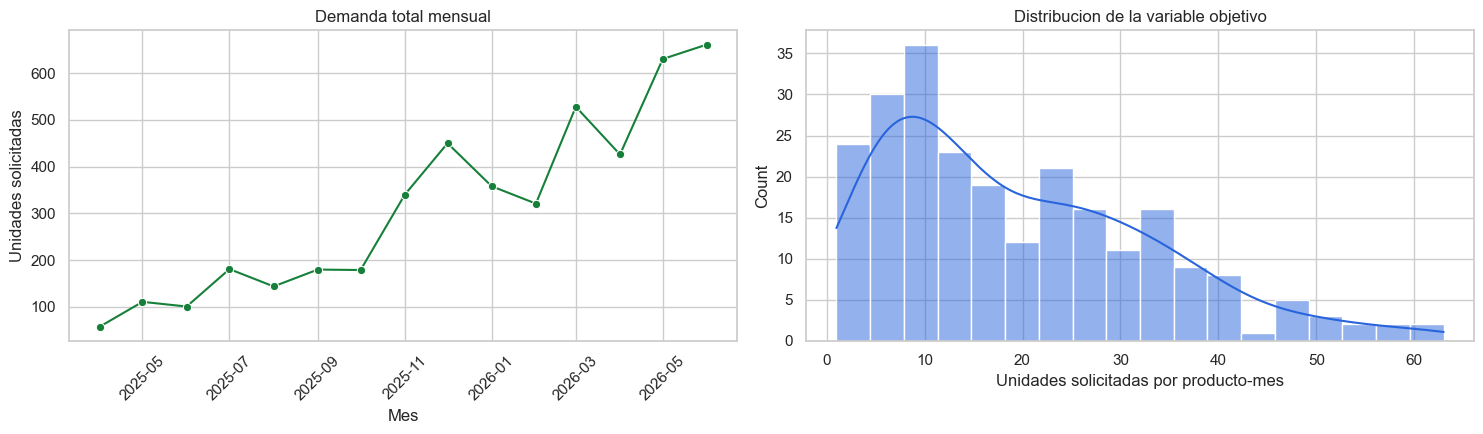

,Y_unidades_solicitadas_mes
count,240.000000
mean,19.450000
std,13.690145
min,1.000000
25%,8.000000
50%,16.000000
75%,28.000000
max,63.000000


In [127]:
demanda_por_mes = demanda_modelable.groupby('mes_objetivo', as_index=False)[TARGET].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.lineplot(data=demanda_por_mes, x='mes_objetivo', y=TARGET, marker='o', color='#16803a', ax=axes[0])
axes[0].set_title('Demanda total mensual')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Unidades solicitadas')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(data=demanda_modelable, x=TARGET, bins=18, kde=True, color='#2864dc', ax=axes[1])
axes[1].set_title('Distribucion de la variable objetivo')
axes[1].set_xlabel('Unidades solicitadas por producto-mes')

plt.tight_layout()
plt.show()

demanda_modelable[TARGET].describe().to_frame(TARGET)

## CRISP-DM 3/6 - Preparacion de variables

La variable objetivo es continua. Se eliminan metadatos y columnas que no deben ser predictores. Se conserva `product_id` como categoria porque identifica patrones base de cada aroma; no se interpreta como un numero.

`mes_objetivo` solo sirve para ordenar cronologicamente las particiones. De ella se deriva `tendencia_calendario_meses`, que es conocida al inicio del mes que se desea estimar.

In [128]:
mes_inicial = demanda_modelable['mes_objetivo'].min()
demanda_modelable['tendencia_calendario_meses'] = (
    (demanda_modelable['mes_objetivo'].dt.year - mes_inicial.year) * 12
    + demanda_modelable['mes_objetivo'].dt.month
    - mes_inicial.month
).astype(float)

columnas_categoricas = ['product_id', 'categoria']
columnas_numericas = [
    'demanda_lag_1m',
    'demanda_lag_2m',
    'demanda_lag_3m',
    'promedio_demanda_3m',
    'pedidos_lag_1m',
    'precio_promedio_lag_1m',
    'rating_promedio_al_corte',
    'cantidad_resenas_al_corte',
    'numero_mes',
    'tendencia_calendario_meses',
]
columnas_x = columnas_categoricas + columnas_numericas
columnas_excluidas = ['fecha_corte', 'mes_objetivo', 'producto', TARGET, 'generation_run_id', 'is_synthetic']

trazabilidad = pd.DataFrame([
    ['product_id', 'productos._id / pedidos.items[].productId', 'Categoria codificada con one-hot', 'X categorica'],
    ['categoria', 'productos.category', 'Categoria codificada con one-hot', 'X categorica'],
    ['demanda_lag_1m', 'pedidos.items[].requestedQuantity + createdAt', 'Suma del mes anterior', 'X numerica'],
    ['demanda_lag_2m', 'pedidos.items[].requestedQuantity + createdAt', 'Suma de dos meses antes', 'X numerica'],
    ['demanda_lag_3m', 'pedidos.items[].requestedQuantity + createdAt', 'Suma de tres meses antes', 'X numerica'],
    ['promedio_demanda_3m', 'Tres rezagos anteriores', 'Promedio de demanda_lag_1m a demanda_lag_3m', 'X numerica'],
    ['pedidos_lag_1m', 'pedidos._id + createdAt', 'Cantidad de pedidos del mes anterior', 'X numerica'],
    ['precio_promedio_lag_1m', 'pedidos.items[].unitPrice', 'Precio promedio del mes anterior', 'X numerica'],
    ['rating_promedio_al_corte', 'resenas_producto.rating + createdAt', 'Promedio disponible antes del corte', 'X numerica'],
    ['cantidad_resenas_al_corte', 'resenas_producto._id + createdAt', 'Cantidad acumulada antes del corte', 'X numerica'],
    ['numero_mes', 'mes_objetivo', 'Mes del calendario, conocido antes de predecir', 'X numerica'],
    ['tendencia_calendario_meses', 'mes_objetivo', 'Meses transcurridos desde el inicio', 'X numerica'],
    [TARGET, 'pedidos.items[].requestedQuantity', 'Suma durante mes_objetivo', 'Y continua'],
], columns=['columna_final', 'origen_mongo', 'transformacion', 'rol'])

trazabilidad

,columna_final,origen_mongo,transformacion,rol
0,product_id,productos._id / pedidos.items[].productId,Categoria codificada con one-hot,X categorica
1,categoria,productos.category,Categoria codificada con one-hot,X categorica
2,demanda_lag_1m,pedidos.items[].requestedQuantity + createdAt,Suma del mes anterior,X numerica
3,demanda_lag_2m,pedidos.items[].requestedQuantity + createdAt,Suma de dos meses antes,X numerica
4,demanda_lag_3m,pedidos.items[].requestedQuantity + createdAt,Suma de tres meses antes,X numerica
5,promedio_demanda_3m,Tres rezagos anteriores,Promedio de demanda_lag_1m a demanda_lag_3m,X numerica
6,pedidos_lag_1m,pedidos._id + createdAt,Cantidad de pedidos del mes anterior,X numerica
7,precio_promedio_lag_1m,pedidos.items[].unitPrice,Precio promedio del mes anterior,X numerica
8,rating_promedio_al_corte,resenas_producto.rating + createdAt,Promedio disponible antes del corte,X numerica
9,cantidad_resenas_al_corte,resenas_producto._id + createdAt,Cantidad acumulada antes del corte,X numerica


### Analisis exploratorio ampliado

Antes de entrenar se exploran la variabilidad, la distribucion y la relacion de las variables con la demanda mensual. Estas visualizaciones sirven para detectar patrones, escalas diferentes y posibles relaciones utiles; no sustituyen la validacion temporal ni prueban causalidad.

In [129]:
columnas_perfil = columnas_numericas + [TARGET]

perfil_numerico = pd.DataFrame({
    'valores_distintos': demanda_modelable[columnas_perfil].nunique(),
    'varianza': demanda_modelable[columnas_perfil].var(),
    'minimo': demanda_modelable[columnas_perfil].min(),
    'mediana': demanda_modelable[columnas_perfil].median(),
    'maximo': demanda_modelable[columnas_perfil].max(),
}).round(2)

perfil_numerico

,valores_distintos,varianza,minimo,mediana,maximo
demanda_lag_1m,48,163.27,0.00,14.00,63.0
demanda_lag_2m,43,126.50,0.00,11.00,51.0
demanda_lag_3m,42,122.68,0.00,9.50,51.0
promedio_demanda_3m,93,113.58,0.33,11.33,47.0
pedidos_lag_1m,38,95.84,0.00,11.00,49.0
precio_promedio_lag_1m,62,3.97,51.00,60.00,60.0
rating_promedio_al_corte,100,0.24,1.00,4.30,5.0
cantidad_resenas_al_corte,35,100.26,0.00,9.00,37.0
numero_mes,12,10.07,1.00,6.00,12.0
tendencia_calendario_meses,15,18.74,0.00,7.00,14.0


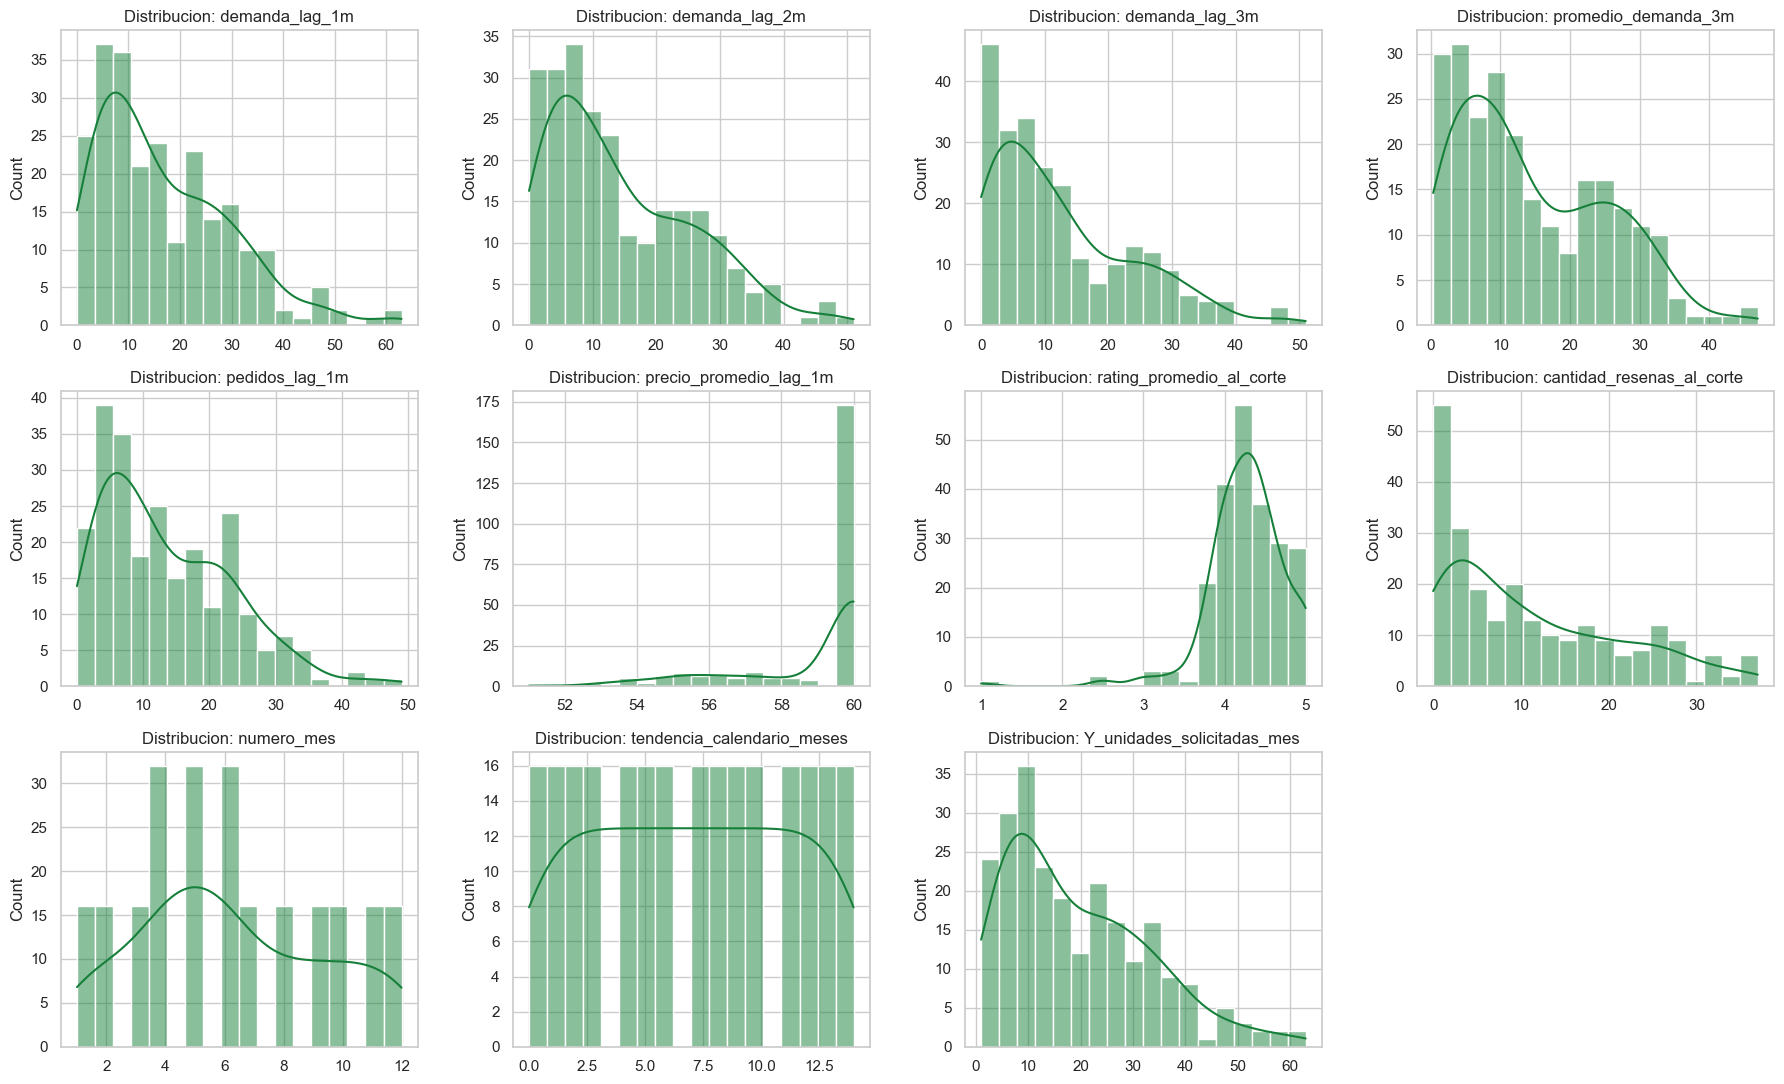

In [130]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))

for eje, columna in zip(axes.flat, columnas_perfil):
    sns.histplot(data=demanda_modelable, x=columna, bins=18, kde=True, color='#16803a', ax=eje)
    eje.set_title(f'Distribucion: {columna}')
    eje.set_xlabel('')

for eje in axes.flat[len(columnas_perfil):]:
    eje.axis('off')

plt.tight_layout()
plt.show()

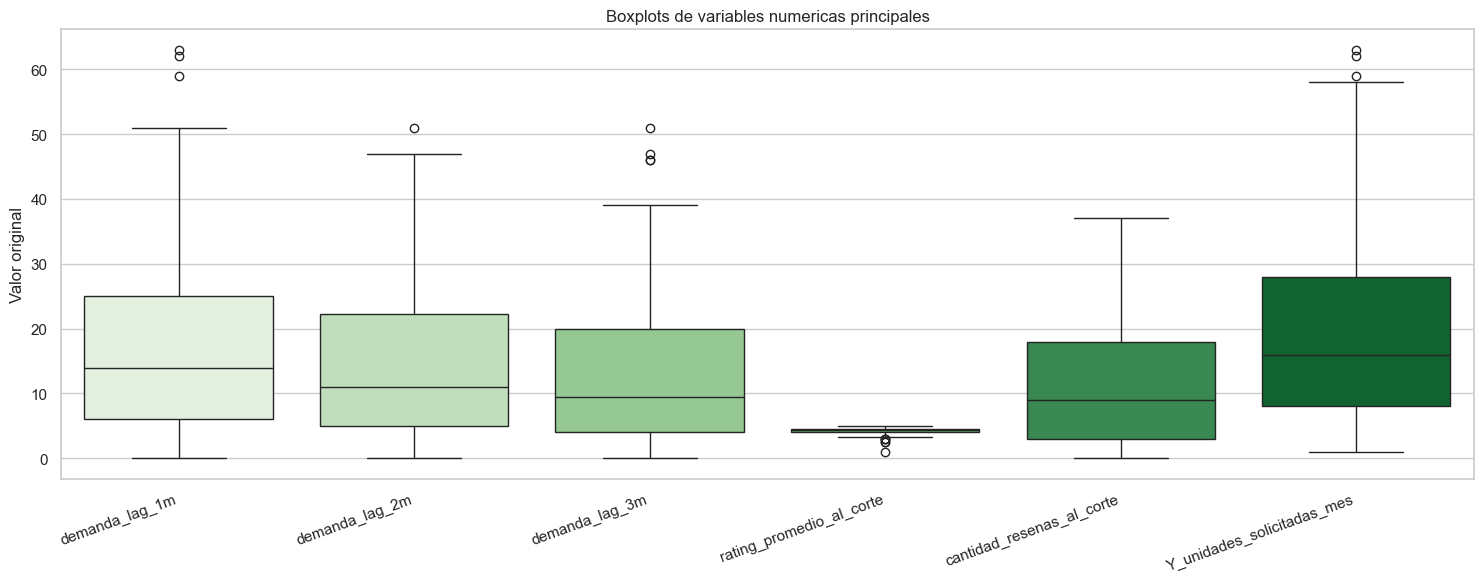

In [131]:
columnas_boxplot = [
    'demanda_lag_1m',
    'demanda_lag_2m',
    'demanda_lag_3m',
    'rating_promedio_al_corte',
    'cantidad_resenas_al_corte',
    TARGET,
]

plt.figure(figsize=(15, 6))
sns.boxplot(data=demanda_modelable[columnas_boxplot], palette='Greens')
plt.title('Boxplots de variables numericas principales')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Valor original')
plt.tight_layout()
plt.show()

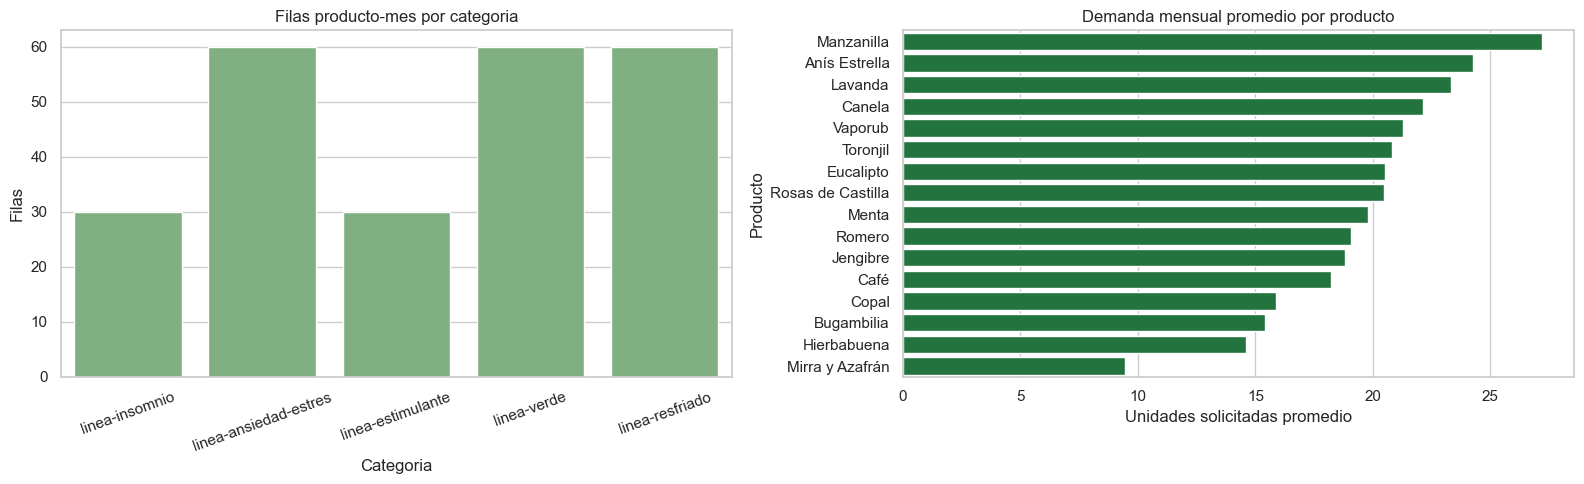

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=demanda_modelable, x='categoria', color='#78b87a', ax=axes[0])
axes[0].set_title('Filas producto-mes por categoria')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Filas')
axes[0].tick_params(axis='x', rotation=20)

demanda_por_producto = (
    demanda_modelable.groupby('producto', as_index=False)[TARGET]
    .mean()
    .sort_values(TARGET, ascending=False)
)
sns.barplot(data=demanda_por_producto, x=TARGET, y='producto', color='#16803a', ax=axes[1])
axes[1].set_title('Demanda mensual promedio por producto')
axes[1].set_xlabel('Unidades solicitadas promedio')
axes[1].set_ylabel('Producto')

plt.tight_layout()
plt.show()

### Matriz de correlacion y relacion con la meta

La matriz se calcula unicamente con variables numericas ya disponibles antes de conocer el mes objetivo. Se revisa especialmente la relacion entre los rezagos de demanda y `Y_unidades_solicitadas_mes`; las variables del futuro no se incorporan como predictores.

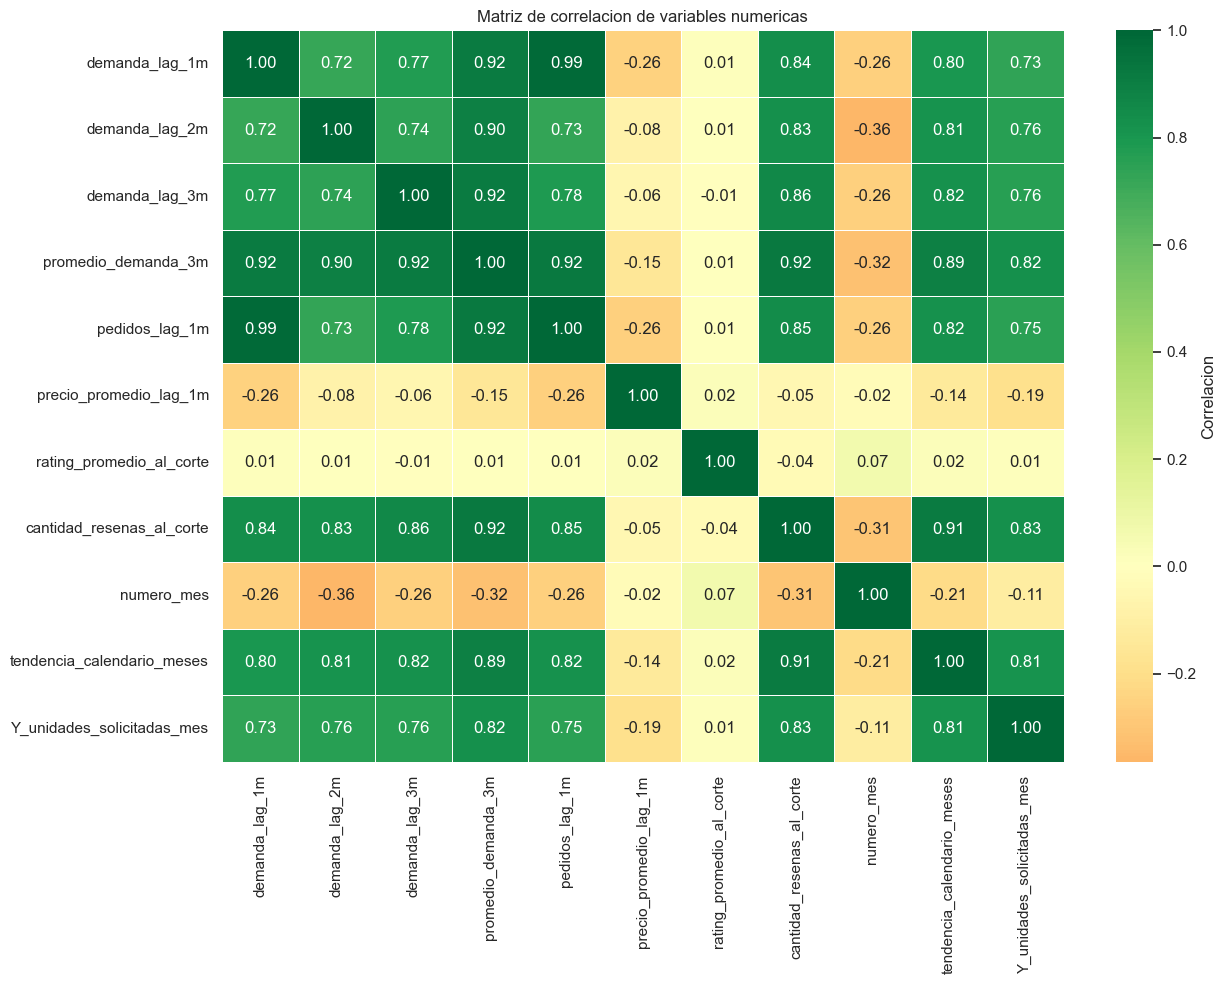

,correlacion_con_Y
cantidad_resenas_al_corte,0.830733
promedio_demanda_3m,0.824535
tendencia_calendario_meses,0.812229
demanda_lag_2m,0.761382
demanda_lag_3m,0.759843
pedidos_lag_1m,0.753717
demanda_lag_1m,0.734340
precio_promedio_lag_1m,-0.188525
numero_mes,-0.113232
rating_promedio_al_corte,0.013520


In [133]:
matriz_correlacion = demanda_modelable[columnas_perfil].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlacion'},
)
plt.title('Matriz de correlacion de variables numericas')
plt.tight_layout()
plt.show()

correlacion_con_y = (
    matriz_correlacion[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
    .to_frame('correlacion_con_Y')
)

correlacion_con_y

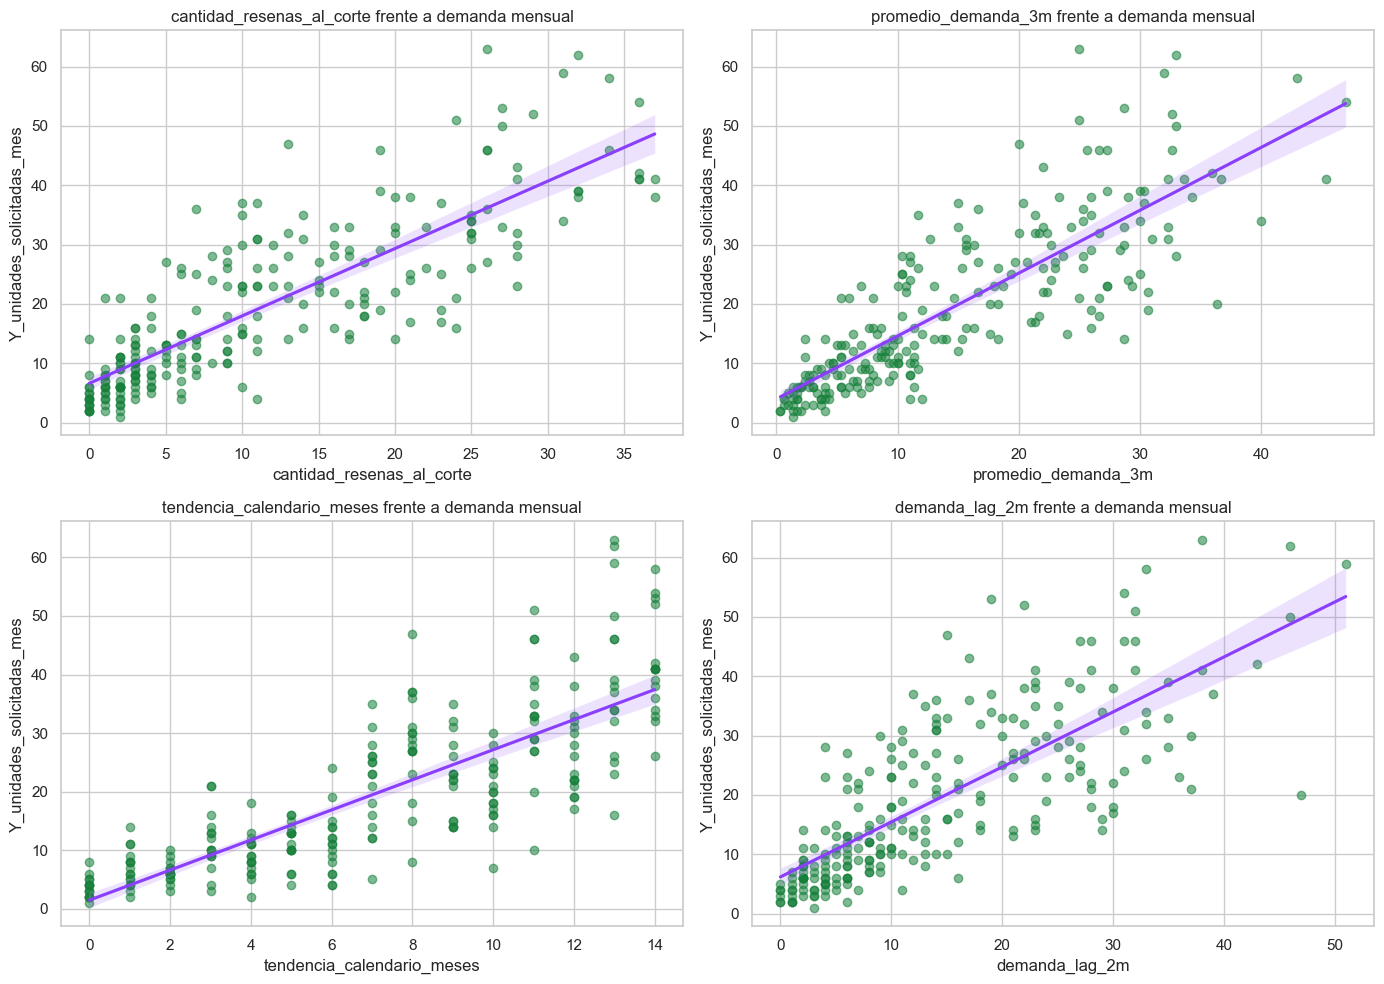

In [134]:
variables_mas_relacionadas = correlacion_con_y.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for eje, columna in zip(axes.flat, variables_mas_relacionadas):
    sns.regplot(
        data=demanda_modelable,
        x=columna,
        y=TARGET,
        scatter_kws={'alpha': 0.55, 'color': '#16803a'},
        line_kws={'color': '#8a3ffc'},
        ax=eje,
    )
    eje.set_title(f'{columna} frente a demanda mensual')

plt.tight_layout()
plt.show()

### Division cronologica

Los tres meses mas recientes se reservan para la prueba final. Los tres meses anteriores se usan para elegir la regularizacion de Ridge. Los meses iniciales quedan para entrenar. No se usa una division aleatoria porque la prediccion siempre debe respetar el paso del tiempo.

In [135]:
meses_ordenados = sorted(demanda_modelable['mes_objetivo'].unique())
meses_prueba = meses_ordenados[-3:]
meses_validacion = meses_ordenados[-6:-3]
meses_entrenamiento = meses_ordenados[:-6]

entrenamiento_crudo = demanda_modelable[demanda_modelable['mes_objetivo'].isin(meses_entrenamiento)].copy()
validacion_cruda = demanda_modelable[demanda_modelable['mes_objetivo'].isin(meses_validacion)].copy()
desarrollo_crudo = demanda_modelable[demanda_modelable['mes_objetivo'] < meses_prueba[0]].copy()
prueba_final_cruda = demanda_modelable[demanda_modelable['mes_objetivo'].isin(meses_prueba)].copy()

assert entrenamiento_crudo['mes_objetivo'].max() < validacion_cruda['mes_objetivo'].min()
assert validacion_cruda['mes_objetivo'].max() < prueba_final_cruda['mes_objetivo'].min()

particiones = pd.DataFrame([
    ['Entrenamiento para configuracion', len(entrenamiento_crudo), entrenamiento_crudo['mes_objetivo'].min().strftime('%Y-%m'), entrenamiento_crudo['mes_objetivo'].max().strftime('%Y-%m')],
    ['Validacion cronologica', len(validacion_cruda), validacion_cruda['mes_objetivo'].min().strftime('%Y-%m'), validacion_cruda['mes_objetivo'].max().strftime('%Y-%m')],
    ['Prueba final cronologica', len(prueba_final_cruda), prueba_final_cruda['mes_objetivo'].min().strftime('%Y-%m'), prueba_final_cruda['mes_objetivo'].max().strftime('%Y-%m')],
], columns=['particion', 'filas', 'inicio', 'fin'])

particiones

,particion,filas,inicio,fin
0,Entrenamiento para configuracion,144,2025-04,2025-12
1,Validacion cronologica,48,2026-01,2026-03
2,Prueba final cronologica,48,2026-04,2026-06


### Tratamiento de nulos, conversion categorica y escalado para validacion

Se aplica el tratamiento solo porque la revision encontro nulos reales despues de exigir tres rezagos. Las medianas se obtienen **unicamente** del entrenamiento. Despues, `pd.get_dummies` convierte producto y categoria a columnas numericas. Ridge necesita escalado porque sus coeficientes son sensibles a escalas distintas; las columnas binarias no se escalan.

In [136]:
X_entrenamiento = entrenamiento_crudo[columnas_x].copy()
X_validacion = validacion_cruda[columnas_x].copy()
y_entrenamiento = entrenamiento_crudo[TARGET].copy()
y_validacion = validacion_cruda[TARGET].copy()

columnas_con_nulos_reales = nulos_modelables.loc[
    nulos_modelables['nulos'] > 0, 'columna'
].tolist()
columnas_con_nulos_reales = [columna for columna in columnas_con_nulos_reales if columna in columnas_numericas]

medianas_entrenamiento = {}
for columna in columnas_con_nulos_reales:
    medianas_entrenamiento[columna] = float(X_entrenamiento[columna].median())
    X_entrenamiento[columna] = X_entrenamiento[columna].fillna(medianas_entrenamiento[columna])
    X_validacion[columna] = X_validacion[columna].fillna(medianas_entrenamiento[columna])

X_entrenamiento = pd.get_dummies(
    X_entrenamiento,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_validacion = pd.get_dummies(
    X_validacion,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_validacion = X_validacion.reindex(columns=X_entrenamiento.columns, fill_value=0.0)

escalador_validacion = StandardScaler()
X_entrenamiento.loc[:, columnas_numericas] = escalador_validacion.fit_transform(
    X_entrenamiento[columnas_numericas]
)
X_validacion.loc[:, columnas_numericas] = escalador_validacion.transform(
    X_validacion[columnas_numericas]
)

resumen_preparacion = pd.DataFrame([
    ['Nulos tratados con mediana de entrenamiento', ', '.join(columnas_con_nulos_reales)],
    ['Columnas despues de one-hot', X_entrenamiento.shape[1]],
    ['Nulos en X_entrenamiento', int(X_entrenamiento.isna().sum().sum())],
    ['Nulos en X_validacion', int(X_validacion.isna().sum().sum())],
], columns=['comprobacion', 'valor'])

resumen_preparacion

,comprobacion,valor
0,Nulos tratados con mediana de entrenamiento,"precio_promedio_lag_1m, rating_promedio_al_corte"
1,Columnas despues de one-hot,31
2,Nulos en X_entrenamiento,0
3,Nulos en X_validacion,0


## CRISP-DM 4/6 - Modelo Ridge y eleccion de alpha

Ridge es una regresion lineal regularizada. Se mantiene un solo tipo de modelo y se prueban cuatro valores de `alpha`; se elige el que obtiene menor MAE en la validacion cronologica. El conjunto de prueba final sigue aislado.

In [137]:
resultados_configuracion = []

for alpha in [1.0, 5.0, 10.0, 20.0]:
    ridge_validacion = Ridge(alpha=alpha)
    ridge_validacion.fit(X_entrenamiento, y_entrenamiento)
    prediccion_validacion = np.clip(ridge_validacion.predict(X_validacion), 0, None)

    resultados_configuracion.append({
        'alpha': alpha,
        'MAE_validacion': mean_absolute_error(y_validacion, prediccion_validacion),
        'RMSE_validacion': mean_squared_error(y_validacion, prediccion_validacion) ** 0.5,
        'R2_validacion': r2_score(y_validacion, prediccion_validacion),
    })

resultados_configuracion = pd.DataFrame(resultados_configuracion).sort_values(
    ['MAE_validacion', 'RMSE_validacion', 'R2_validacion'],
    ascending=[True, True, False],
).reset_index(drop=True)

alpha_seleccionado = float(resultados_configuracion.loc[0, 'alpha'])
resultados_configuracion

,alpha,MAE_validacion,RMSE_validacion,R2_validacion
0,5.0,6.670247,8.689805,0.143519
1,1.0,6.707541,9.299389,0.019141
2,10.0,6.787979,8.663234,0.148749
3,20.0,6.829966,8.656765,0.150020


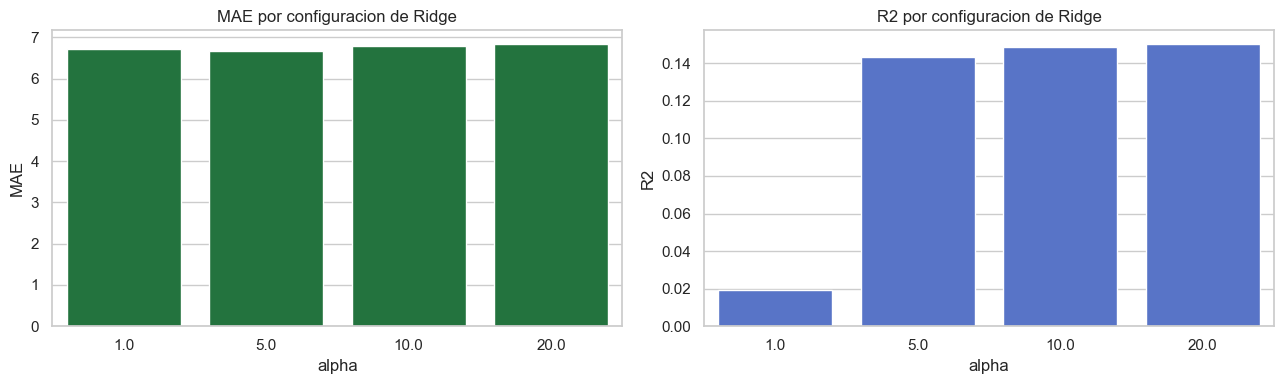

,criterio,valor
0,Alpha seleccionado,5.0


In [138]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=resultados_configuracion, x='alpha', y='MAE_validacion', color='#16803a', ax=axes[0])
axes[0].set_title('MAE por configuracion de Ridge')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('MAE')

sns.barplot(data=resultados_configuracion, x='alpha', y='R2_validacion', color='#466bd9', ax=axes[1])
axes[1].set_title('R2 por configuracion de Ridge')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('R2')

plt.tight_layout()
plt.show()

pd.DataFrame([['Alpha seleccionado', alpha_seleccionado]], columns=['criterio', 'valor'])

## CRISP-DM 5/6 - Preparacion para la prueba final

Con el valor de `alpha` elegido, se vuelve a preparar el desarrollo completo: todos los meses anteriores a la prueba final. Las medianas y el escalador se ajustan solo con este desarrollo y luego se aplican a los tres meses finales.

In [139]:
X_desarrollo = desarrollo_crudo[columnas_x].copy()
X_prueba_final = prueba_final_cruda[columnas_x].copy()
y_desarrollo = desarrollo_crudo[TARGET].copy()
y_prueba_final = prueba_final_cruda[TARGET].copy()

medianas_desarrollo = {}
for columna in columnas_con_nulos_reales:
    medianas_desarrollo[columna] = float(X_desarrollo[columna].median())
    X_desarrollo[columna] = X_desarrollo[columna].fillna(medianas_desarrollo[columna])
    X_prueba_final[columna] = X_prueba_final[columna].fillna(medianas_desarrollo[columna])

X_desarrollo = pd.get_dummies(
    X_desarrollo,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_prueba_final = pd.get_dummies(
    X_prueba_final,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_prueba_final = X_prueba_final.reindex(columns=X_desarrollo.columns, fill_value=0.0)

escalador_final = StandardScaler()
X_desarrollo.loc[:, columnas_numericas] = escalador_final.fit_transform(
    X_desarrollo[columnas_numericas]
)
X_prueba_final.loc[:, columnas_numericas] = escalador_final.transform(
    X_prueba_final[columnas_numericas]
)

X_desarrollo.shape, X_prueba_final.shape

((192, 31), (48, 31))

In [140]:
modelo_final = Ridge(alpha=alpha_seleccionado)
modelo_final.fit(X_desarrollo, y_desarrollo)

prediccion_final = np.clip(modelo_final.predict(X_prueba_final), 0, None)
prediccion_base = prueba_final_cruda['promedio_demanda_3m'].to_numpy()

metricas_prueba = pd.DataFrame([
    ['MAE Ridge', mean_absolute_error(y_prueba_final, prediccion_final)],
    ['RMSE Ridge', mean_squared_error(y_prueba_final, prediccion_final) ** 0.5],
    ['R2 Ridge', r2_score(y_prueba_final, prediccion_final)],
    ['MAE linea base de 3 meses', mean_absolute_error(y_prueba_final, prediccion_base)],
    ['Mejora MAE contra linea base (%)', 100 * (1 - mean_absolute_error(y_prueba_final, prediccion_final) / mean_absolute_error(y_prueba_final, prediccion_base))],
], columns=['metrica', 'valor'])

metricas_prueba

,metrica,valor
0,MAE Ridge,7.072362
1,RMSE Ridge,9.815500
2,R2 Ridge,0.340343
3,MAE linea base de 3 meses,10.368058
4,Mejora MAE contra linea base (%),31.787019


### Interpretacion del modelo final

Ridge es un modelo lineal regularizado. Sus coeficientes permiten observar que variables codificadas aportan mas al resultado. La magnitud se interpreta con cautela: indica influencia dentro de este dataset y de esta preparacion, no una causa clinica ni comercial definitiva.

C:\Users\David\AppData\Local\Temp\ipykernel_20228\591799219.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


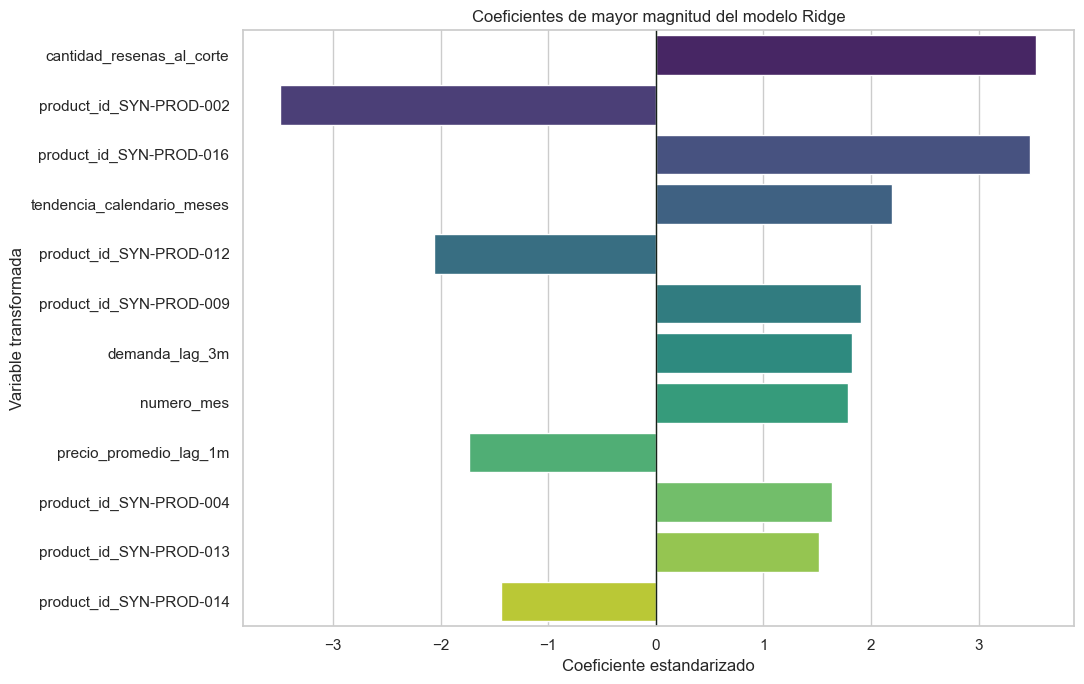

,variable,coeficiente,magnitud
7,cantidad_resenas_al_corte,3.535778,3.535778
11,product_id_SYN-PROD-002,-3.490473,3.490473
25,product_id_SYN-PROD-016,3.479479,3.479479
9,tendencia_calendario_meses,2.197301,2.197301
21,product_id_SYN-PROD-012,-2.061155,2.061155
18,product_id_SYN-PROD-009,1.908897,1.908897
2,demanda_lag_3m,1.825051,1.825051
8,numero_mes,1.788858,1.788858
5,precio_promedio_lag_1m,-1.741470,1.741470
13,product_id_SYN-PROD-004,1.640427,1.640427


In [141]:
importancia_ridge = pd.DataFrame({
    'variable': X_desarrollo.columns,
    'coeficiente': modelo_final.coef_,
})
importancia_ridge['magnitud'] = importancia_ridge['coeficiente'].abs()
importancia_ridge = importancia_ridge.sort_values('magnitud', ascending=False)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=importancia_ridge.head(12),
    x='coeficiente',
    y='variable',
    palette='viridis',
)
plt.axvline(0, color='#172219', linewidth=1)
plt.title('Coeficientes de mayor magnitud del modelo Ridge')
plt.xlabel('Coeficiente estandarizado')
plt.ylabel('Variable transformada')
plt.tight_layout()
plt.show()

importancia_ridge.head(12)

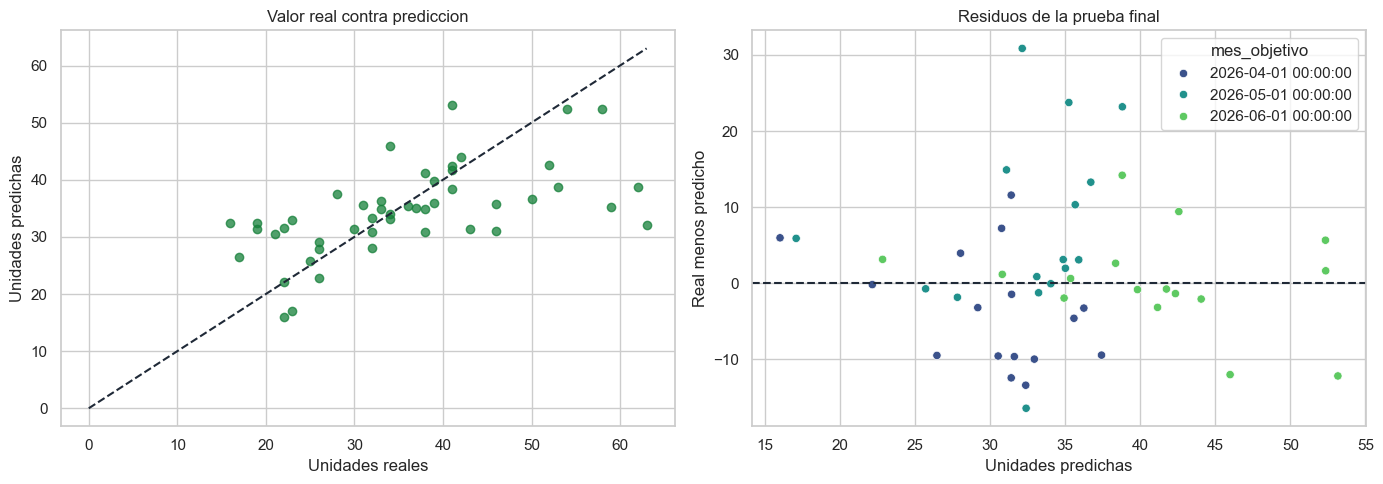

,mes_objetivo,product_id,producto,Y_unidades_solicitadas_mes,prediccion_ridge,residuo,error_absoluto
256,2026-05-01,SYN-PROD-001,Toronjil,63,32.148846,30.851154,30.851154
261,2026-05-01,SYN-PROD-006,Lavanda,59,35.253075,23.746925,23.746925
259,2026-05-01,SYN-PROD-004,Anís Estrella,62,38.816345,23.183655,23.183655
270,2026-05-01,SYN-PROD-015,Bugambilia,16,32.409148,-16.409148,16.409148
262,2026-05-01,SYN-PROD-007,Menta,46,31.102308,14.897692,14.897692
276,2026-06-01,SYN-PROD-005,Eucalipto,53,38.806290,14.193710,14.193710
244,2026-04-01,SYN-PROD-005,Eucalipto,19,32.383714,-13.383714,13.383714
271,2026-05-01,SYN-PROD-016,Manzanilla,50,36.716183,13.283817,13.283817
240,2026-04-01,SYN-PROD-001,Toronjil,19,31.416693,-12.416693,12.416693
275,2026-06-01,SYN-PROD-004,Anís Estrella,41,53.165661,-12.165661,12.165661


In [142]:
resultados_prueba = prueba_final_cruda[
    ['mes_objetivo', 'product_id', 'producto', TARGET]
].copy()
resultados_prueba['prediccion_ridge'] = prediccion_final
resultados_prueba['residuo'] = resultados_prueba[TARGET] - resultados_prueba['prediccion_ridge']
resultados_prueba['error_absoluto'] = resultados_prueba['residuo'].abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
limite = max(resultados_prueba[TARGET].max(), resultados_prueba['prediccion_ridge'].max())
axes[0].scatter(resultados_prueba[TARGET], resultados_prueba['prediccion_ridge'], color='#16803a', alpha=0.75)
axes[0].plot([0, limite], [0, limite], '--', color='#1f2937')
axes[0].set_title('Valor real contra prediccion')
axes[0].set_xlabel('Unidades reales')
axes[0].set_ylabel('Unidades predichas')

sns.scatterplot(data=resultados_prueba, x='prediccion_ridge', y='residuo', hue='mes_objetivo', palette='viridis', ax=axes[1])
axes[1].axhline(0, linestyle='--', color='#1f2937')
axes[1].set_title('Residuos de la prueba final')
axes[1].set_xlabel('Unidades predichas')
axes[1].set_ylabel('Real menos predicho')

plt.tight_layout()
plt.show()

resultados_prueba.sort_values('error_absoluto', ascending=False).head(10)

**Interpretacion.** MAE expresa el error promedio directamente en unidades por producto-mes. RMSE aumenta el peso de errores grandes. R2 compara el modelo con una prediccion constante. La prueba final siempre corresponde a meses posteriores a los usados para elegir `alpha`.

La linea base usa el promedio de los tres meses anteriores. El modelo se considera util solo si reduce el error frente a esa referencia sencilla.

## CRISP-DM 6/6 - Entrenamiento final y exportacion para Flask

Despues de evaluar, el modelo se ajusta con todas las filas que tienen tres rezagos. Se guardan en un solo archivo el modelo Ridge, el escalador, las medianas y las columnas creadas por one-hot. Flask debera usar esa misma informacion al reconstruir X desde MongoDB.

No se exporta ni se usara el CSV en produccion.

In [143]:
futuro = pd.read_csv(
    EXPORTS_DIR / 'dataset_demanda_inferencia.csv',
    dtype={'product_id': 'string', 'producto': 'string', 'categoria': 'string'},
)
futuro['fecha_corte'] = pd.to_datetime(futuro['fecha_corte'], errors='coerce')
futuro['mes_objetivo'] = pd.to_datetime(futuro['mes_objetivo'], format='%Y-%m', errors='coerce')
futuro['tendencia_calendario_meses'] = (
    (futuro['mes_objetivo'].dt.year - mes_inicial.year) * 12
    + futuro['mes_objetivo'].dt.month
    - mes_inicial.month
).astype(float)

X_produccion = demanda_modelable[columnas_x].copy()
X_futuro = futuro[columnas_x].copy()
y_produccion = demanda_modelable[TARGET].copy()

medianas_produccion = {}
for columna in columnas_con_nulos_reales:
    medianas_produccion[columna] = float(X_produccion[columna].median())
    X_produccion[columna] = X_produccion[columna].fillna(medianas_produccion[columna])
    X_futuro[columna] = X_futuro[columna].fillna(medianas_produccion[columna])

X_produccion = pd.get_dummies(
    X_produccion,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_futuro = pd.get_dummies(
    X_futuro,
    columns=columnas_categoricas,
    dtype=float,
).astype(float)
X_futuro = X_futuro.reindex(columns=X_produccion.columns, fill_value=0.0)

escalador_produccion = StandardScaler()
X_produccion.loc[:, columnas_numericas] = escalador_produccion.fit_transform(
    X_produccion[columnas_numericas]
)
X_futuro.loc[:, columnas_numericas] = escalador_produccion.transform(
    X_futuro[columnas_numericas]
)

modelo_produccion = Ridge(alpha=alpha_seleccionado)
modelo_produccion.fit(X_produccion, y_produccion)
prediccion_futura = np.clip(modelo_produccion.predict(X_futuro), 0, None)

futuro[['product_id', 'producto', 'mes_objetivo']].assign(
    prediccion_unidades=np.round(prediccion_futura).astype(int)
).head()

,product_id,producto,mes_objetivo,prediccion_unidades
0,SYN-PROD-001,Toronjil,2026-07-01,53
1,SYN-PROD-002,Mirra y Azafrán,2026-07-01,25
2,SYN-PROD-003,Copal,2026-07-01,36
3,SYN-PROD-004,Anís Estrella,2026-07-01,58
4,SYN-PROD-005,Eucalipto,2026-07-01,43


In [144]:
modelo_path = ARTIFACT_DIR / 'monthly-demand-flask-pipeline.v1.joblib'
manifiesto_path = ARTIFACT_DIR / 'monthly-demand-flask-manifest.v1.json'

paquete_modelo = {
    'model': modelo_produccion,
    'scaler': escalador_produccion,
    'rawFeatureColumns': columnas_x,
    'numericColumns': columnas_numericas,
    'categoricalColumns': columnas_categoricas,
    'encodedFeatureColumns': X_produccion.columns.tolist(),
    'missingValueMedians': medianas_produccion,
    'targetColumn': TARGET,
    'selectedAlpha': alpha_seleccionado,
    'randomSeed': SEED,
}

joblib.dump(paquete_modelo, modelo_path)

manifiesto_modelo = {
    'schemaVersion': 'flask-monthly-demand.v1',
    'artifactType': 'monthly-demand-regression',
    'model': {
        'name': 'Ridge',
        'version': '2.0.0-simple-steps',
        'alpha': alpha_seleccionado,
        'randomSeed': SEED,
        'isSynthetic': True,
    },
    'target': {
        'column': TARGET,
        'unit': 'unidades solicitadas por producto durante un mes',
        'predictionMoment': 'antes del inicio de mes_objetivo',
    },
    'featureContract': {
        'orderedColumns': columnas_x,
        'rawColumns': columnas_x,
        'numericColumns': columnas_numericas,
        'categoricalColumns': columnas_categoricas,
        'encodedColumns': X_produccion.columns.tolist(),
        'minimumHistoryMonths': 3,
        'eligibilityRule': 'Predecir solo si existen demanda_lag_1m, demanda_lag_2m y demanda_lag_3m.',
        'fallbackPolicy': 'Si falta historial, informar historial_insuficiente y no inventar una prediccion Ridge.',
        'nullPolicy': 'Eliminar filas sin tres rezagos; imputar solo precio y rating faltantes con la mediana de entrenamiento.',
        'featureDefinitions': trazabilidad[trazabilidad['rol'].str.startswith('X')].to_dict(orient='records'),
    },
    'sourceContract': {
        'collections': ['pedidos', 'productos', 'resenas_producto'],
        'aggregationUnit': 'producto-mes',
        'futureRuntime': 'Flask calcula las mismas variables desde MongoDB y no usa CSV.',
    },
    'evaluation': {
        'finalTestMonths': [mes.strftime('%Y-%m') for mes in meses_prueba],
        'mae': float(metricas_prueba.loc[metricas_prueba['metrica'].eq('MAE Ridge'), 'valor'].iloc[0]),
        'rmse': float(metricas_prueba.loc[metricas_prueba['metrica'].eq('RMSE Ridge'), 'valor'].iloc[0]),
        'r2': float(metricas_prueba.loc[metricas_prueba['metrica'].eq('R2 Ridge'), 'valor'].iloc[0]),
    },
}

manifiesto_path.write_text(
    json.dumps(manifiesto_modelo, ensure_ascii=False, indent=2) + '\n',
    encoding='utf-8',
)

modelo_path.relative_to(REPO_ROOT).as_posix(), manifiesto_path.relative_to(REPO_ROOT).as_posix()

('ml/artifacts/monthly-demand-flask-pipeline.v1.joblib',
 'ml/artifacts/monthly-demand-flask-manifest.v1.json')

In [145]:
paquete_recargado = joblib.load(modelo_path)
manifiesto_recargado = json.loads(manifiesto_path.read_text(encoding='utf-8'))

assert paquete_recargado['encodedFeatureColumns'] == X_produccion.columns.tolist()
assert manifiesto_recargado['featureContract']['minimumHistoryMonths'] == 3
assert len(prediccion_futura) == len(futuro)

pd.DataFrame([
    ['Modelo recargado', paquete_recargado['model'].__class__.__name__],
    ['Alpha exportado', paquete_recargado['selectedAlpha']],
    ['Columnas codificadas', len(paquete_recargado['encodedFeatureColumns'])],
    ['Predicciones futuras generadas', len(prediccion_futura)],
], columns=['comprobacion', 'valor'])

,comprobacion,valor
0,Modelo recargado,Ridge
1,Alpha exportado,5.0
2,Columnas codificadas,31
3,Predicciones futuras generadas,16


## Limites y siguiente etapa

- El dataset actual es 100 % sintetico y sirve para demostrar un proceso reproducible; las metricas no sustituyen una validacion con ventas reales.
- Un producto nuevo con menos de tres meses de historial no debe recibir una prediccion Ridge; Flask debe marcarlo como `historial_insuficiente` o aplicar una politica de negocio separada.
- La prediccion estima demanda, no garantiza ventas ni recomienda una compra automatica.
- Antes de conectar Flask se debe mantener la misma definicion de venta, fecha y cantidad tanto en MongoDB como en el entrenamiento.
- Al existir nuevos meses de datos, se debe ejecutar nuevamente este flujo, validar metricas y activar solo un artefacto aprobado.

**Referencias:** Hoerl, A. E. y Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*.

In [146]:
controles_finales = pd.DataFrame([
    ['No se generaron nulos artificiales', True],
    ['Sin nulos en X de prueba', int(X_prueba_final.isna().sum().sum()) == 0],
    ['Division cronologica respetada', entrenamiento_crudo['mes_objetivo'].max() < validacion_cruda['mes_objetivo'].min() < prueba_final_cruda['mes_objetivo'].min()],
    ['Modelo y artefacto exportados', modelo_path.exists() and manifiesto_path.exists()],
    ['Predicciones no negativas', bool((prediccion_futura >= 0).all())],
], columns=['comprobacion', 'resultado'])

assert controles_finales['resultado'].all()
controles_finales

,comprobacion,resultado
0,No se generaron nulos artificiales,True
1,Sin nulos en X de prueba,True
2,Division cronologica respetada,True
3,Modelo y artefacto exportados,True
4,Predicciones no negativas,True
